In [3]:
#load data
import pandas as pd
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\House_Price_Prediction\data\House Price India.csv")
df.head()

,id,Date,bedrooms,bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
1,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
2,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
3,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000
4,6762813105,42491,3,2.50,2600,4750,1.0,0,0,4,...,1951,0,122007,52.9133,-114.590,2380,4750,1,67,790000


In [4]:
y=df['Price'] #target
features=['lot area','bedrooms','bathrooms','number of floors']
X=df[features]

In [5]:
#handle missing values
X=X.fillna(X.mean())

In [6]:
#train-validation split
from sklearn.model_selection import train_test_split
X_train,X_valid,y_train,y_valid=train_test_split(X,y,random_state=1)

In [7]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(random_state=1)
model.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
#model validation (MAE)
from sklearn.metrics import mean_absolute_error
preds=model.predict(X_valid)
mae=mean_absolute_error(y_valid,preds)
print("MAE:",mae)

MAE: 232119.31822704664


In [10]:
#Random Forest Model
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=1,n_estimators=100)
rf_model.fit(X_train,y_train)
rf_preds=rf_model.predict(X_valid)
rf_mae=mean_absolute_error(y_valid,rf_preds)

print("Random Forest MAE : ",rf_mae)

Random Forest MAE :  191695.61828663244


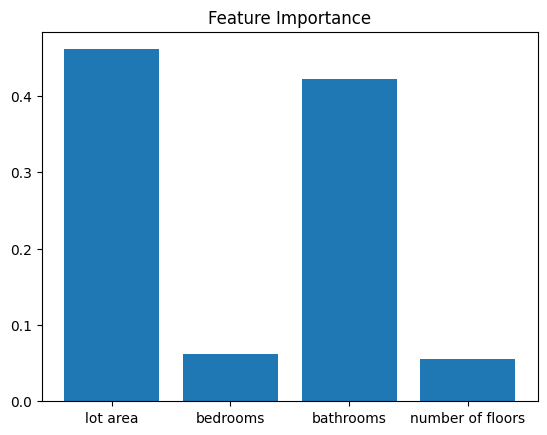

In [11]:
#feature importance
import matplotlib.pyplot as plt

importances=rf_model.feature_importances_
plt.bar(features,importances)
plt.title("Feature Importance")
plt.show()

#key insights
-Random Forest outperforms simple tree model
-Area is the most important factor affecting price
-Model validation prevents overfitting
-MAE gives clear real-world error interpretation